# Driver Monitoring System — Smoking Detection Module

This notebook covers the training pipeline for the smoking detection module of the Driver Monitoring System (DMS) graduation project. The goal of this module is to detect whether a driver is smoking while operating the vehicle, using a YOLO object detector trained on a custom labeled dataset.

The notebook is organized as follows:

1. Environment setup (Google Drive mount)
2. Dataset extraction and inspection
3. Label cleanup and remapping
4. Dataset configuration (`data.yaml`)
5. Visual sanity check of annotations
6. Model training (YOLO11m)
7. Model evaluation on the validation set
8. Inference test on a sample image

All training was done on Google Colab using a T4 GPU, with the dataset and trained weights stored on Google Drive so that progress is not lost between sessions.

## 1. Environment Setup

Since this notebook runs on Google Colab, the dataset and the training outputs need to persist across sessions. Mounting Google Drive lets us read the zipped dataset and later save the trained weights directly to Drive instead of the temporary Colab storage, which gets wiped when the runtime disconnects.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Dataset Extraction and Inspection

The raw dataset was collected and annotated separately, then uploaded to Drive as a zip archive (already split into `train` / `valid` / `test`). The cell below extracts it locally to `/content/dataset1` and prints how many images and label files exist per split. This is mainly a quick check to confirm the extraction worked correctly and that the number of images roughly matches the number of label files before moving forward.

In [ ]:
import zipfile
import os

zip_source = '/content/drive/MyDrive/smoking/Driver Monitoring system smoking data (1).zip'
dest_path = '/content/dataset1'

with zipfile.ZipFile(zip_source, 'r') as zip_ref:
    zip_ref.extractall(dest_path)

print("Files extracted. Contents of /content/dataset1:")
print(os.listdir(dest_path))

from pathlib import Path

DATA_ROOT = Path('/content/dataset1')
print('\nDataset structure:')
for split in ['train', 'valid', 'test']:
    split_dir = DATA_ROOT / split
    if split_dir.exists():
        imgs_dir = split_dir / 'images'
        lbls_dir = split_dir / 'labels'
        img_count = len(list(imgs_dir.glob('*'))) if imgs_dir.exists() else 0
        lbl_count = len(list(lbls_dir.glob('*.txt'))) if lbls_dir.exists() else 0
        print(f'   {split:6s} | images: {img_count:5d} | labels: {lbl_count:5d}')
    else:
        print(f'   {split:6s} | skipped')

Files extracted. Contents of /content/dataset1:
['valid', 'README.dataset.txt', 'train', 'test', 'README.roboflow.txt', 'data.yaml']

Dataset structure:
   train  | images:  2703 | labels:  2703
   valid  | images:   617 | labels:   617
   test   | images:   537 | labels:   537


## 3. Label Cleanup

The original dataset was exported with multiple classes (it looks like it came from a source project with class id `3` corresponding to smoking, alongside other classes not relevant here). Since this module only cares about a single class, all label files are scanned and only lines starting with class id `3` are kept, then remapped to id `0`. Any other class present in the original annotations is dropped, so what remains is a clean single-class dataset ready for training.

In [ ]:
import os
from pathlib import Path

dataset_root = Path('/content/dataset1')

print("Starting label filtering...")

for split in ['train', 'valid', 'test']:
    labels_dir = dataset_root / split / 'labels'
    if labels_dir.exists():
        for label_file in labels_dir.glob('*.txt'):
            with open(label_file, 'r') as f:
                lines = f.readlines()

            new_lines = []
            for line in lines:
                if line.startswith('3 '):
                    new_lines.append(line.replace('3 ', '0 ', 1))

            with open(label_file, 'w') as f:
                f.writelines(new_lines)

print("Filtering complete: All labels now only contain Smoking class (mapped to 0).")

Starting label filtering...
Filtering complete: All labels now only contain Smoking class (mapped to 0).


## 4. Dataset Configuration

Ultralytics YOLO expects a `data.yaml` file describing where the train/val/test images live and what classes exist. After cleaning the labels, this file is generated automatically instead of writing it by hand, which avoids typos in the paths and keeps it in sync with the actual folder structure.

In [ ]:
import yaml

data_config = {
    'train': '/content/dataset1/train/images',
    'val': '/content/dataset1/valid/images',
    'test': '/content/dataset1/test/images',
    'nc': 1,
    'names': ['smoking']
}

with open('/content/dataset1/data.yaml', 'w') as f:
    yaml.dump(data_config, f)

print("data.yaml updated.")

data.yaml updated.


## 5. Visual Sanity Check

Before spending time on training, it's worth confirming visually that the bounding boxes actually line up with the smoking class in the images, and that the label remapping from the previous step didn't break anything. A random sample of training images is drawn and the YOLO-format boxes are converted to pixel coordinates and plotted on top of each image.

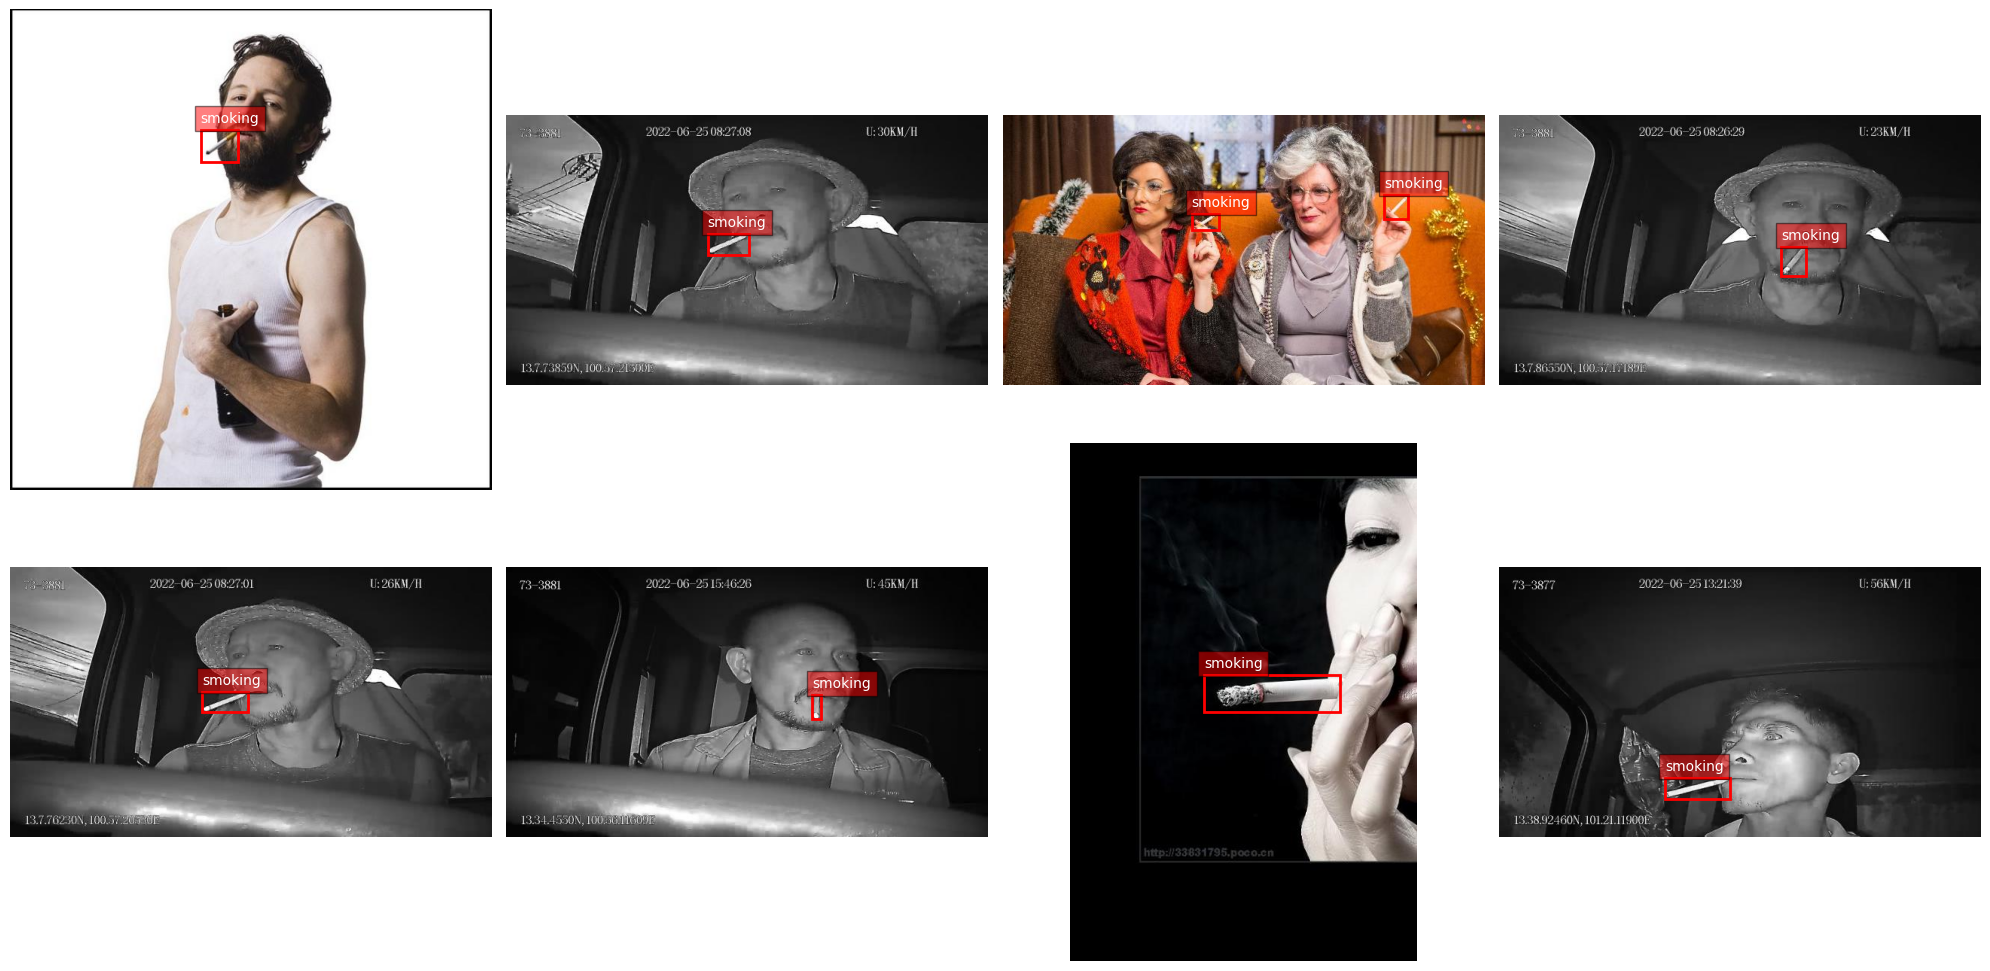

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.image as mpimg
from pathlib import Path
import random

DATA_ROOT = Path('/content/dataset1')
CLASS_NAMES = ['smoking']

def draw_boxes(img_path, label_path, ax):
    img = mpimg.imread(str(img_path))
    h, w = img.shape[:2]
    ax.imshow(img)

    if Path(label_path).exists():
        with open(label_path, 'r') as f:
            for line in f.readlines():
                parts = line.strip().split()
                if len(parts) >= 5:
                    cls_id = int(parts[0])
                    cx, cy, bw, bh = map(float, parts[1:5])

                    x1 = (cx - bw / 2) * w
                    y1 = (cy - bh / 2) * h

                    rect = patches.Rectangle((x1, y1), bw * w, bh * h, linewidth=2, edgecolor='red', facecolor='none')
                    ax.add_patch(rect)
                    ax.text(x1, y1 - 10, CLASS_NAMES[cls_id], color='white', fontsize=10, bbox=dict(facecolor='red', alpha=0.5))

    ax.axis('off')

train_imgs = list((DATA_ROOT / 'train' / 'images').glob('*'))
samples = random.sample(train_imgs, min(8, len(train_imgs)))

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for i, img_p in enumerate(samples):
    lbl_p = DATA_ROOT / 'train' / 'labels' / (img_p.stem + '.txt')
    draw_boxes(img_p, lbl_p, axes.flatten()[i])

plt.tight_layout()
plt.show()

## 6. Training Setup

With the dataset verified, the `ultralytics` package is installed to get access to the YOLO training and inference API.

In [ ]:
!pip install ultralytics -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 170.1 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 68.5 MB/s eta 0:00:00


## 7. Model Training

The detector is trained starting from the `yolo11m.pt` pretrained checkpoint rather than from scratch, which speeds up convergence since the backbone already knows general visual features. Training runs for 140 epochs with the AdamW optimizer and a fairly low learning rate (`lr0 = 0.001`), plus a short warmup period to stabilize the first few epochs.

A few augmentation choices worth noting:
- `mosaic = 0.8` — helps the model generalize by combining multiple images, useful given the dataset isn't huge.
- `mixup` and `copy_paste` are disabled, since blending images too aggressively didn't seem to help for this single-class problem.
- `fliplr = 0.5` and small `degrees` / `perspective` jitter — reasonable augmentations for a driver-facing camera without distorting the scene too much.

`patience = 30` enables early stopping if validation performance stalls, and all runs/weights are saved directly under the Drive project folder so the best checkpoint survives runtime resets.

In [ ]:
from pathlib import Path
from ultralytics import YOLO

DATA_ROOT = Path('/content/dataset1')
YAML_PATH = DATA_ROOT / 'data.yaml'
RUNS_DIR = Path('/content/drive/MyDrive/Smoking_Detection_Project')
TRAIN_NAME = 'smoking_detection_exp'

if not RUNS_DIR.exists():
    RUNS_DIR.mkdir(parents=True, exist_ok=True)

model = YOLO('yolo11m.pt')

results = model.train(
    data           = str(YAML_PATH),
    epochs         = 140,
    imgsz          = 640,
    batch          = 16,
    lr0            = 0.001,
    optimizer      = 'AdamW',
    warmup_epochs  = 5,
    patience       = 30,
    mosaic         = 0.8,
    mixup          = 0.0,
    copy_paste     = 0.0,
    fliplr         = 0.5,
    degrees        = 10.0,
    perspective    = 0.0005,
    plots          = True,
    save           = True,
    project        = str(RUNS_DIR),
    name           = TRAIN_NAME,
    exist_ok       = True
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.89 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset1/data.yaml, degrees=10.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=140, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, 

## 8. Evaluation

After training finishes, the best checkpoint (`best.pt`) is reloaded and validated again on the dataset defined in `data.yaml`. This gives the standard detection metrics — mAP@0.5, mAP@0.5:0.95, precision and recall — which are printed at the end. These numbers are the main quantitative measure of how well the smoking detector performs and will be used later in the performance summary.

In [ ]:
from ultralytics import YOLO
best_weights = '/content/drive/MyDrive/Smoking_Detection_Project/smoking_detection_exp/weights/best.pt'
yaml_path = '/content/dataset1/data.yaml'
model = YOLO(best_weights)
metrics = model.val(data=yaml_path)
print('\n========== Final Validation Results ==========')
print(f'mAP@0.5       : {metrics.box.map50:.4f}')
print(f'mAP@0.5:0.95  : {metrics.box.map:.4f}')
print(f'Precision     : {metrics.box.mp:.4f}')
print(f'Recall        : {metrics.box.mr:.4f}')


Ultralytics 8.4.89 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11m summary (fused): 126 layers, 20,030,803 parameters, 0 gradients, 67.6 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1411.2±521.1 MB/s, size: 30.0 KB)
val: Scanning /content/dataset1/valid/labels.cache... 617 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 617/617 199.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 39/39 2.4it/s 16.0s
                   all        617        655      0.948      0.895       0.93      0.574
Speed: 1.4ms preprocess, 17.6ms inference, 0.0ms loss, 1.4ms postprocess per image
Results saved to /content/runs/detect/val-3

========== Final Validation Results ==========
mAP@0.5       : 0.9296
mAP@0.5:0.95  : 0.5735
Precision     : 0.9482
Recall        : 0.8949


## 9. Inference Test

As a final check, the trained model is run on a single external test image (not part of the training/validation set) to see how it behaves qualitatively. The predicted boxes are drawn on the image with `results[0].plot()` and displayed inline, and the annotated result is also saved back to Drive for later reference in the report.


image 1/1 /content/drive/MyDrive/smoking/Smoking-and-Driving.jpg: 288x640 1 smoking, 53.0ms
Speed: 1.9ms preprocess, 53.0ms inference, 4.9ms postprocess per image at shape (1, 3, 288, 640)


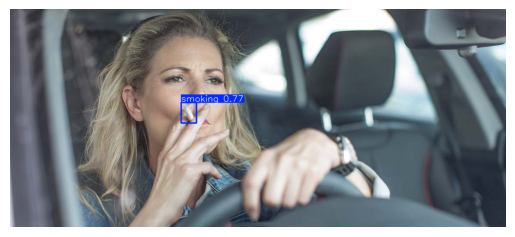

'/content/drive/MyDrive/smoker/result_detected.jpg'

In [ ]:
from ultralytics import YOLO
import matplotlib.pyplot as plt

model_path = '/content/drive/MyDrive/Smoking_Detection_Project/smoking_detection_exp/weights/best.pt'
model = YOLO(model_path)

img_path = '/content/drive/MyDrive/smoking/Smoking-and-Driving.jpg'

results = model.predict(source=img_path, conf=0.5)

annotated_image = results[0].plot()
plt.imshow(annotated_image[:, :, ::-1])
plt.axis('off')
plt.show()

results[0].save(filename='/content/drive/MyDrive/smoker/result_detected.jpg')

## Summary and Conclusion

This notebook trained a YOLO11m-based detector for the smoking class as part of the DMS project. The main steps were: extracting and cleaning the raw annotations down to a single class, generating a proper `data.yaml`, visually confirming the labels were correct, training for 140 epochs with augmentation tuned for this dataset, and validating the resulting weights.

The final `best.pt` checkpoint and its validation metrics (mAP, precision, recall) represent the output of this module. These weights can be plugged into the full DMS pipeline alongside the other detection modules (e.g. seatbelt detection) to flag risky driver behavior in real time.

Possible improvements for future work: collecting more training data under different lighting/camera angles, and running a more systematic hyperparameter search instead of the manually chosen values used here.